In [1]:
import pyarrow as pa
import pyarrow.parquet as pq
print(pa.__version__)


16.1.0


In [13]:
import databento as db

client = db.Historical("***REMOVED***")
data = client.timeseries.get_range(
    dataset="OPRA.PILLAR",
    schema="trades",
    stype_in="parent",
    symbols=["AAPL.OPT"],
    start="2024-08-09T09:30-04:00",
    end="2024-08-09T10:00-04:00",
)
df = data.to_df()

In [14]:
df

,ts_event,rtype,publisher_id,instrument_id,action,side,depth,price,size,flags,ts_in_delta,sequence,symbol
ts_recv,,,,,,,,,,,,,
2024-08-09 13:30:00.008689345+00:00,2024-08-09 13:30:00.008481024+00:00,0,25,16789321,T,N,0,0.06,3,194,0,504826,AAPL 240809C00217500
2024-08-09 13:30:00.021880156+00:00,2024-08-09 13:30:00.021671680+00:00,0,26,33562568,T,N,0,0.10,6,194,0,601850,AAPL 240816C00230000
2024-08-09 13:30:00.032886565+00:00,2024-08-09 13:30:00.032677376+00:00,0,26,33565009,T,N,0,0.77,4,194,0,601926,AAPL 240920P00175000
2024-08-09 13:30:00.036991612+00:00,2024-08-09 13:30:00.036783616+00:00,0,26,16786836,T,N,0,0.08,1,194,0,505218,AAPL 240809P00202500
2024-08-09 13:30:00.109699333+00:00,2024-08-09 13:30:00.109490688+00:00,0,26,33562507,T,N,0,2.23,2,194,0,602937,AAPL 240816C00215000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-08-09 13:59:58.801315993+00:00,2024-08-09 13:59:58.801104640+00:00,0,31,33569755,T,N,0,6.80,2,194,0,277397483,AAPL 240816C00207500
2024-08-09 13:59:58.962219427+00:00,2024-08-09 13:59:58.962010112+00:00,0,37,16784368,T,N,0,1.24,1,194,0,248227915,AAPL 240809C00212500
2024-08-09 13:59:59.036621416+00:00,2024-08-09 13:59:59.036411136+00:00,0,28,33559467,T,N,0,0.02,2,194,0,277430136,AAPL 240816C00240000


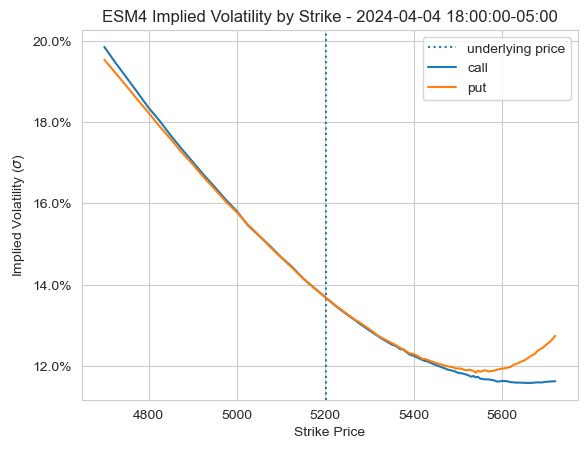

In [15]:
from collections.abc import Iterable
import databento as db
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.ticker import PercentFormatter
from scipy.optimize import root_scalar
from scipy.stats import norm

dataset = "GLBX.MDP3"

def black_76(
    S: float,
    K: float,
    T: float,
    sigma: float,
    r: float = 0.05,
    is_call_option: bool = True,
) -> float:
    """
    Calculate an option price from the Black-76 model.

    Parameters
    ----------
    S : float
        Current underlying price.
    K : float
        Option strike price.
    T : float
        Time to expiration in years.
    sigma : float
        Implied volatility, annualized.
    r : float, default 0.05
        The risk free interest rate, annualized.
    is_call_option : bool, default True
        Flag to indicate the option is a call or put.

    Returns
    -------
    float

    """
    d1 = (np.log(S / K) + (sigma**2 / 2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    discount_factor = np.exp(-r * T)

    cp = 1 if is_call_option else -1
    return discount_factor * cp * (S * norm.cdf(cp * d1) - K * norm.cdf(cp * d2))


def get_front_month_symbol(
    parent: str,
    start: pd.Timestamp,
) -> str:
    """
    Get the symbol of the front month futures contract of a given parent symbol.

    Parameters
    ----------
    parent : str
        The parent symbol, such as ES.
    start : pd.Timestamp
        The date to obtain the front month symbol for.

    Returns
    -------
    str

    """
    front_def = client.timeseries.get_range(
        dataset=db.Dataset.GLBX_MDP3,
        schema=db.Schema.DEFINITION,
        symbols=[f"{parent}.c.0"],
        stype_in=db.SType.CONTINUOUS,
        start=start.date(),
        end=(start + pd.Timedelta(days=1)).date(),
    ).to_df()
    return front_def.iloc[0]["raw_symbol"]


def get_options_chain(
    parent: str,
    underlying: str,
    start: pd.Timestamp,
) -> pd.DataFrame:
    """
    Retrieve the definitions of all options contract of the given parent symbol with for the underlying.

    Parameters
    ----------
    parent : str
        The parent symbol, such as ES.
    underlying : str
        The underlying contract for the option.
    start : pd.Timestamp
        The date to obtain the definitions for.

    Returns
    -------
    pd.DataFrame

    """
    options_def = client.timeseries.get_range(
        dataset=dataset,
        schema="definition",
        symbols=f"{parent}.OPT",
        stype_in="parent",
        start=start.date(),
    )

    df = options_def.to_df()
    df = df[df["underlying"] == underlying]
    df = df[df["instrument_class"].isin(("C", "P"))]
    df["years_to_expiration"] = (df["expiration"] - start).dt.days / 365
    return df.sort_values("strike_price")


def get_midprice(
    symbols: Iterable[str],
    start: pd.Timestamp,
    end: pd.Timestamp,
) -> pd.Series:
    """
    Get the last top-of-book midprice for one or more symbols between the `start` and `end` times.

    Parameters
    ----------
    symbols : Iterable[str]
        A collection of symbols to retrieve the midprices for.
    start : pd.Timestamp
        The start time.
    end : pd.Timestamp
        The end time (exclusive).

    Returns
    -------
    pd.Series

    """
    price_df = client.timeseries.get_range(
        dataset=dataset,
        schema="mbp-1",
        symbols=symbols,
        start=start,
        end=end,
    ).to_df()

    price_df = price_df.groupby("symbol").last()
    price_df["midprice"] = np.mean(price_df[["bid_px_00", "ask_px_00"]], axis=1)

    return price_df["midprice"]


def find_sigma(
    row: pd.Series,
) -> float:
    """
    Find the roots of the Black-76 model by varying sigma, implied volatility.

    This function is for use with `pandas.Dataframe.apply`. Each row should contain
    a column for "strike_price", "years_to_expiration", "instrument_class", "midprice",
    and "underlying_price",

    If the optimization fails, `numpy.nan` is returned.

    Parameters
    ----------
    row : pd.Series
        A series of data to process.

    Returns
    -------
    float | numpy.nan

    """

    def f(sigma: float) -> float:
        return row["midprice"] - black_76(
            S=row["underlying_price"],
            K=row["strike_price"],
            T=row["years_to_expiration"],
            sigma=sigma,
            is_call_option=row["instrument_class"] == "C",
        )

    result = root_scalar(f, x0=0.1, x1=0.5)
    if result.converged:
        return result.root
    print(
        f"Could not find sigma for {row['raw_symbol']} with midprice {row['midprice']}",
    )
    return np.nan


# First, create a historical client
client = db.Historical(key="***REMOVED***")

# Now, define some parameters for the calculation
parent_symbol = "ES"
start = pd.Timestamp("2024-04-04T17:00:00", tz="US/Central")
end = pd.Timestamp("2024-04-04T18:00:00", tz="US/Central")

# Get the front month futures contract for the parent symbol
front_month_symbol = get_front_month_symbol(
    parent=parent_symbol,
    start=start,
)

# Get the definitions for all options with the front-month future as the underlying
options_chain = get_options_chain(
    parent=parent_symbol,
    underlying=front_month_symbol,
    start=start,
)

# Retrieve the midprices for the options and front-month future
midprices = get_midprice(
    symbols=[front_month_symbol, *options_chain["raw_symbol"]],
    start=start,
    end=end,
)

# Then, join the options definitions with the midprices
underlying_price = midprices.loc[front_month_symbol]
options_chain = options_chain.join(midprices, on="symbol").dropna(subset="midprice")
options_chain["underlying_price"] = underlying_price

# Remove options with strike prices far from the underlying price
options_chain = options_chain[
    abs(options_chain["strike_price"] - underlying_price) <= underlying_price * 0.1
]

# Next, find the implied volatility for each option
options_chain["sigma"] = options_chain.apply(
    find_sigma,
    axis=1,
)

# Separate options into calls and puts
call_options = options_chain[options_chain["instrument_class"] == "C"]
put_options = options_chain[options_chain["instrument_class"] == "P"]

# Finally, plot each curve of implied volatility by strike price
plt.axvline(
    underlying_price,
    label="underlying price",
    linestyle=":",
)
plt.plot(
    "strike_price",
    "sigma",
    data=call_options,
    label="call",
)
plt.plot(
    "strike_price",
    "sigma",
    data=put_options,
    label="put",
)
plt.title(f"{front_month_symbol} Implied Volatility by Strike - {end}")
plt.ylabel("Implied Volatility ($\\sigma$)")
plt.xlabel("Strike Price")
plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.legend()
plt.show()


In [16]:
options_chain

,ts_event,rtype,publisher_id,instrument_id,raw_symbol,security_update_action,instrument_class,min_price_increment,display_factor,expiration,...,maturity_week,user_defined_instrument,contract_multiplier_unit,flow_schedule_type,tick_rule,symbol,years_to_expiration,midprice,underlying_price,sigma
ts_recv,,,,,,,,,,,,,,,,,,,,,
2024-04-04 00:00:00+00:00,2024-03-31 12:00:30.008000+00:00,19,1,266463,ESM4 P4700,A,P,NaN,0.01,2024-06-21 13:30:00+00:00,...,255,N,127,127,15,ESM4 P4700,0.210959,28.375,5201.375,0.195345
2024-04-04 00:00:00+00:00,2024-03-31 12:00:30.908000+00:00,19,1,730949,ESM4 C4700,A,C,NaN,0.01,2024-06-21 13:30:00+00:00,...,255,N,127,127,15,ESM4 C4700,0.210959,526.000,5201.375,0.198506
2024-04-04 00:00:00+00:00,2024-03-31 12:00:27.808000+00:00,19,1,42431167,ESM4 C4725,A,C,NaN,0.01,2024-06-21 13:30:00+00:00,...,255,N,127,127,15,ESM4 C4725,0.210959,503.000,5201.375,0.194641
2024-04-04 00:00:00+00:00,2024-03-31 12:00:30.408000+00:00,19,1,42426732,ESM4 P4725,A,P,NaN,0.01,2024-06-21 13:30:00+00:00,...,255,N,127,127,15,ESM4 P4725,0.210959,30.375,5201.375,0.192146
2024-04-04 00:00:00+00:00,2024-03-31 12:00:28.708000+00:00,19,1,4163556,ESM4 C4750,A,C,NaN,0.01,2024-06-21 13:30:00+00:00,...,255,N,127,127,15,ESM4 C4750,0.210959,480.250,5201.375,0.191004
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-04-04 00:00:00+00:00,2024-03-31 12:00:30.708000+00:00,19,1,792874,ESM4 C5700,A,C,NaN,0.01,2024-06-21 13:30:00+00:00,...,255,N,127,127,15,ESM4 C5700,0.210959,5.050,5201.375,0.116132
2024-04-04 00:00:00+00:00,2024-03-31 12:00:31.008000+00:00,19,1,42396774,ESM4 C5710,A,C,NaN,0.01,2024-06-21 13:30:00+00:00,...,255,N,127,127,15,ESM4 C5710,0.210959,4.675,5201.375,0.116195
2024-04-04 00:00:00+00:00,2024-03-31 12:00:26.008000+00:00,19,1,42396775,ESM4 P5710,A,P,NaN,0.01,2024-06-21 13:30:00+00:00,...,255,N,127,127,15,ESM4 P5710,0.210959,510.375,5201.375,0.126149
